# Layer 2 extension: risk-adjusted RQ2 and the context of biased passes

This notebook builds on `layer2_bias_analysis.ipynb` and the coordinate fix in `layer1_visual_constraint.ipynb`. It does not change any earlier result. It asks two follow-up questions about the RQ2 forward-bias rate (38.9% of passes had a visible, onside, realistic forward option worth more than the pass that was played).

**1. Risk.** The original comparison sets the value of every option as if the pass arrives. A forward pass that fails is worse than a sideways pass that fails, so part of the 38.9% could be players sensibly avoiding risk. Here every pass, real and hypothetical, gets an expected value:

$$EV = xP \cdot V(\text{success}) + (1 - xP) \cdot V(\text{fail})$$

where $V(\text{success})$ is the VAEP value already computed and $V(\text{fail})$ is the VAEP value of the same pass with its result set to fail. A bypassed option now only counts if its expected value beats the expected value of the pass that was actually played.

**2. Context.** Is the bias rate different depending on game state (score and minute), pressure on the passer, the passer's position, and where on the pitch the pass starts?

**Inputs:** `../data/results/candidates_full.pkl`, `../data/results/vaep_models_ext.pkl`, `../data/results/xp_model_full.pkl`, the saved SPADL actions in `../data/matches/` and `../data/matches_extended/`, and the cached StatsBomb events and frames in `../data/statsbomb_cache/`.

## Setup

In [1]:
import glob
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socceraction.vaep.features as fs
from socceraction.vaep.formula import value
from socceraction.spadl import config as spadlconfig

RESULTS = Path('../data/results')
CACHE_DIR = Path('../data/statsbomb_cache')

feature_functions = [
    fs.actiontype_onehot,
    fs.result_onehot,
    fs.startlocation,
    fs.endlocation,
    fs.team,
    fs.time_delta,
]

with open(RESULTS / 'vaep_models_ext.pkl', 'rb') as f:
    models_ext = pickle.load(f)
with open(RESULTS / 'xp_model_full.pkl', 'rb') as f:
    xp_model_full = pickle.load(f)

candidates_full = pd.read_pickle(RESULTS / 'candidates_full.pkl')
candidates_full['match_id'] = candidates_full['match_id'].astype(str)

n_passes = candidates_full.groupby(['match_id', 'original_event_id']).ngroups
orig_rate = candidates_full.groupby(['match_id', 'original_event_id'])['legitimate_forward_progressive'].any().mean()
print(f"{len(candidates_full)} candidate rows, {n_passes} passes, {candidates_full['match_id'].nunique()} matches")
print(f"original forward-bias rate: {orig_rate:.1%} (should be 38.9%)")
print(f"'mirrored' column present: {'mirrored' in candidates_full.columns}")

664518 candidate rows, 98652 passes, 166 matches
original forward-bias rate: 38.9% (should be 38.9%)
'mirrored' column present: True


In [2]:
FAIL_ID = spadlconfig.results.index('fail')


def load_match_actions(mid):
    """The SPADL actions saved for this match in layer 1, in action order."""
    for folder in ['../data/matches', '../data/matches_extended']:
        p = Path(folder) / f'match_{mid}.pkl'
        if p.exists():
            return pd.read_pickle(p)['actions'].sort_values('action_id').reset_index(drop=True)
    raise FileNotFoundError(f"no saved actions for match {mid}")


def batch_window_values(m_actions, pass_idx, end_x, end_y, models, fail=False):
    """Same as the function in the layer 1 coordinate fix section, with one extra option:
    fail=True sets the result of the last action in each window to 'fail', so the VAEP
    model values the pass as if it did not reach the target."""
    pass_idx = np.asarray(pass_idx)
    n = len(pass_idx)
    r0 = m_actions.loc[pass_idx - 2].reset_index(drop=True)
    r1 = m_actions.loc[pass_idx - 1].reset_index(drop=True)
    r2 = m_actions.loc[pass_idx].reset_index(drop=True)
    r2['end_x'] = np.asarray(end_x, dtype=float)
    r2['end_y'] = np.asarray(end_y, dtype=float)
    if fail:
        r2['result_id'] = FAIL_ID
        r2['result_name'] = 'fail'
    rows = pd.concat([r0, r1, r2], ignore_index=True)

    w = np.arange(n)
    i0, i1, i2 = w, n + w, 2 * n + w
    same01 = r0['period_id'].values == r1['period_id'].values
    same12 = r1['period_id'].values == r2['period_id'].values

    cur = np.column_stack([i1, i2]).ravel()
    prev1 = np.column_stack([np.where(same01, i0, i1),
                             np.where(same12, i1, i2)]).ravel()
    prev2 = np.column_stack([np.where(same01, i0, i1),
                             np.where(same12, np.where(same01, i0, i1), i2)]).ravel()

    gs = [rows.iloc[ix].reset_index(drop=True) for ix in (cur, prev1, prev2)]
    X = pd.concat([f(gs) for f in feature_functions], axis=1)
    ps = models['scores'].predict_proba(X)[:, 1]
    pc = models['concedes'].predict_proba(X)[:, 1]
    v = value(gs[0], pd.Series(ps), pd.Series(pc))['vaep_value'].values
    return v[1::2]


def sb_to_spadl(x, y, mirrored):
    """StatsBomb yards (acting team attacking toward x=120) to SPADL metres,
    with socceraction's flip for away-team actions."""
    x = np.clip((np.asarray(x, dtype=float) - 0.5) / 120 * 105, 0, 105)
    y = np.clip(68 - (np.asarray(y, dtype=float) - 0.5) / 80 * 68, 0, 68)
    mirrored = np.asarray(mirrored, dtype=bool)
    return np.where(mirrored, 105 - x, x), np.where(mirrored, 68 - y, y)


def compute_xp_features(passer_loc, target_loc, frame_at_event):
    """Copied unchanged from layer2_bias_analysis.ipynb, used here only to check the faster version below."""
    dx = target_loc[0] - passer_loc[0]
    dy = target_loc[1] - passer_loc[1]
    pass_distance = np.sqrt(dx**2 + dy**2)
    defenders = frame_at_event[frame_at_event['teammate'] == False]
    if defenders.empty:
        nearest_defender_dist = 99.0
        defender_density = 0
    else:
        defender_dists = defenders['location'].apply(
            lambda loc: np.sqrt((loc[0] - target_loc[0])**2 + (loc[1] - target_loc[1])**2)
        )
        nearest_defender_dist = defender_dists.min()
        defender_density = (defender_dists < 5).sum()
    return {'pass_distance': pass_distance,
            'nearest_defender_dist': nearest_defender_dist,
            'defender_density': defender_density}


def rate_ci(df, cols, n_boot=5000, seed=0):
    """Share of passes where each column is True, with 95% intervals from resampling whole matches."""
    per_match = df.groupby('match_id')[cols].agg(['sum', 'count'])
    S = np.column_stack([per_match[(c, 'sum')] for c in cols]).astype(float)
    C = np.column_stack([per_match[(c, 'count')] for c in cols]).astype(float)
    idx = np.random.default_rng(seed).integers(0, len(per_match), size=(n_boot, len(per_match)))
    boot = S[idx].sum(axis=1) / C[idx].sum(axis=1)
    point = S.sum(axis=0) / C.sum(axis=0)
    return pd.DataFrame({'passes': C.sum(axis=0).astype(int), 'rate': point,
                         'ci_low': np.percentile(boot, 2.5, axis=0),
                         'ci_high': np.percentile(boot, 97.5, axis=0)}, index=cols)


print("helpers ready, fail result id =", FAIL_ID)

helpers ready, fail result id = 0


## 1. Information about each pass from the events and freeze frames

One loop over the 166 matches collects everything needed later, per pass:

- **For risk:** the xP features of the pass that was actually played (passer to `pass_end_location`, with the same three features the xP model was trained on), so the real pass gets an xP just like the candidates.
- **Game state:** the score from the passer's team's point of view just before the pass (goals from shots with outcome Goal, plus own goals via the `Own Goal For` event, penalty shootouts excluded), and the minute.
- **Pressure:** StatsBomb's `under_pressure` flag, and the distance from the passer to the nearest opponent in the freeze frame.
- **Position and zone:** the passer's StatsBomb position, grouped into GK, DEF, MID, FWD, and the third of the pitch the pass starts in (StatsBomb coordinates already have the acting team attacking toward x=120).

The defender-distance calculation is done for all passes at once per match instead of one pass at a time, and is checked against the original `compute_xp_features` on a sample.

In [3]:
def position_group(pos):
    if not isinstance(pos, str):
        return np.nan
    if pos == 'Goalkeeper':
        return 'GK'
    if 'Back' in pos:          # centre backs, full backs and wing backs
        return 'DEF'
    if 'Midfield' in pos:
        return 'MID'
    if 'Wing' in pos or 'Forward' in pos or 'Striker' in pos:
        return 'FWD'
    return np.nan


def nearest_opponents(points, frames, px_col, py_col, radius=5.0):
    """For each row of points (with an 'id' column), the distance to the nearest opponent
    in that event's freeze frame and the number of opponents within radius."""
    opp = frames.loc[frames['teammate'] == False, ['id', 'location']]
    opp = pd.DataFrame({'id': opp['id'].values,
                        'ox': opp['location'].str[0].values,
                        'oy': opp['location'].str[1].values})
    m = points[['id', px_col, py_col]].merge(opp, on='id', how='left')
    m['d'] = np.hypot(m['ox'] - m[px_col], m['oy'] - m[py_col])
    m['close'] = m['d'] < radius
    g = m.groupby('id').agg(nearest=('d', 'min'), density=('close', 'sum'))
    g['nearest'] = g['nearest'].fillna(99.0)   # no opponent in the frame, same rule as compute_xp_features
    return g


pass_keys = candidates_full[['match_id', 'original_event_id']].drop_duplicates()
keys_by_match = {mid: g['original_event_id'].values for mid, g in pass_keys.groupby('match_id')}

info_rows = []
check_rows = []
t0 = time.time()
for i, (mid, eids) in enumerate(keys_by_match.items()):
    events = pd.read_pickle(CACHE_DIR / f'events_{mid}.pkl')
    frames = pd.read_pickle(CACHE_DIR / f'frames_{mid}.pkl')

    # goals so far for each team, by event order
    shot_goal = (events['type'] == 'Shot') & (events.get('shot_outcome') == 'Goal') & (events['period'] < 5)
    own_goal = events['type'] == 'Own Goal For'
    goals = events.loc[shot_goal | own_goal, ['index', 'team']]
    teams = events['team'].dropna().unique()
    goal_idx = {t: np.sort(goals.loc[goals['team'] == t, 'index'].values) for t in teams}

    ev = events.set_index('id').loc[eids]
    p = pd.DataFrame({
        'match_id': mid,
        'original_event_id': eids,
        'id': eids,
        'event_index': ev['index'].values,
        'team': ev['team'].values,
        'period': ev['period'].values,
        'minute': ev['minute'].values,
        'under_pressure': ev['under_pressure'].eq(True).values if 'under_pressure' in ev.columns else False,
        'position': ev['position'].values,
        'px': ev['location'].str[0].values,
        'py': ev['location'].str[1].values,
        'ex': ev['pass_end_location'].str[0].values,
        'ey': ev['pass_end_location'].str[1].values,
    })
    p['goals_for'] = [np.searchsorted(goal_idx[t], k) for t, k in zip(p['team'], p['event_index'])]
    p['goals_against'] = [sum(np.searchsorted(goal_idx[o], k) for o in teams if o != t)
                          for t, k in zip(p['team'], p['event_index'])]

    # real pass xP features: distance, and opponents around the pass end
    at_end = nearest_opponents(p, frames, 'ex', 'ey')
    p['real_pass_distance'] = np.hypot(p['ex'] - p['px'], p['ey'] - p['py'])
    p['real_nearest_defender_dist'] = p['id'].map(at_end['nearest']).fillna(99.0).values
    p['real_defender_density'] = p['id'].map(at_end['density']).fillna(0).astype(int).values

    # pressure: nearest opponent to the passer
    at_passer = nearest_opponents(p, frames, 'px', 'py')
    p['passer_nearest_opp'] = p['id'].map(at_passer['nearest']).fillna(99.0).values

    # final score in this match from the goal events, to check against the official result
    check_rows.append({'match_id': mid, **{t: len(goal_idx[t]) for t in teams}})

    # spot check the fast xP features against the original function on a few passes
    if i < 5:
        for _, r in p.sample(min(30, len(p)), random_state=0).iterrows():
            ref = compute_xp_features((r['px'], r['py']), (r['ex'], r['ey']), frames[frames['id'] == r['id']])
            check = (abs(ref['pass_distance'] - r['real_pass_distance']) < 1e-9
                     and abs(ref['nearest_defender_dist'] - r['real_nearest_defender_dist']) < 1e-9
                     and ref['defender_density'] == r['real_defender_density'])
            assert check, f"fast xP features differ from compute_xp_features for event {r['id']}"

    info_rows.append(p.drop(columns=['id']))
    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{len(keys_by_match)}] matches done ({time.time() - t0:.0f}s)")

pass_info = pd.concat(info_rows, ignore_index=True)
X_real = pass_info[['real_pass_distance', 'real_nearest_defender_dist', 'real_defender_density']].copy()
X_real.columns = ['pass_distance', 'nearest_defender_dist', 'defender_density']
pass_info['real_xp'] = xp_model_full.predict_proba(X_real)[:, 1]

print(f"\n{len(pass_info)} passes in {time.time() - t0:.0f}s, fast xP features match the original function on the spot check")
print(f"passes missing a pass end location: {pass_info['ex'].isna().sum()}")
print("\nxP of the passes actually played:")
print(pass_info['real_xp'].describe().round(3).to_string())
print("\nxP of all candidate teammates, for comparison:")
print(candidates_full['xp_value'].describe().round(3).to_string())

[20/166] matches done (4s)
[40/166] matches done (8s)
[60/166] matches done (12s)
[80/166] matches done (16s)
[100/166] matches done (20s)
[120/166] matches done (25s)
[140/166] matches done (29s)
[160/166] matches done (33s)

98652 passes in 35s, fast xP features match the original function on the spot check
passes missing a pass end location: 0

xP of the passes actually played:
count    98652.000
mean         0.878
std          0.113
min          0.000
25%          0.869
50%          0.919
75%          0.941
max          1.000

xP of all candidate teammates, for comparison:
count    660792.000
mean          0.688
std           0.243
min           0.000
25%           0.528
50%           0.757
75%           0.899
max           1.000


**What this shows**

All 98652 passes were found in the events and frames, none is missing a pass end location, and the faster defender-distance code gives exactly the same features as `compute_xp_features` on the spot check.

**Passes players actually made are much safer than the average teammate option.** Real passes have a mean xP of 0.878 (median 0.919), against 0.688 (median 0.757) for all candidate teammates. That is expected: real passes are completed passes the players chose, while the candidates include every teammate in the frame, many of them marked or far away. It also means the risk adjustment is demanding for the candidates, since a bypassed option has to beat a pass that was very likely to arrive.

**One caution.** The xP model was trained on real passes, so its probabilities for hypothetical passes to teammates nobody passed to are an extrapolation.

**Check: do the goal counts reproduce the real results?** If the goal events (shots plus own goals) are being counted correctly, the totals per match should equal the official full-time score (including extra time, excluding penalty shootouts). This needs `statsbombpy` to fetch the match list; if that fails, the rest of the notebook still runs, without the competition column.

In [4]:
import warnings
from statsbombpy import sb
warnings.filterwarnings('ignore', module='statsbombpy')

try:
    match_list = pd.concat([
        sb.matches(competition_id=55, season_id=282).assign(competition='Euro 2024'),
        sb.matches(competition_id=55, season_id=43).assign(competition='Euro 2020'),
        sb.matches(competition_id=43, season_id=106).assign(competition='World Cup 2022'),
    ], ignore_index=True)
    match_list['match_id'] = match_list['match_id'].astype(str)

    counted = pd.DataFrame(check_rows).set_index('match_id')
    mismatches = []
    for _, m in match_list[match_list['match_id'].isin(counted.index)].iterrows():
        row = counted.loc[m['match_id']]
        ours = (row.get(m['home_team'], np.nan), row.get(m['away_team'], np.nan))
        if ours != (m['home_score'], m['away_score']):
            mismatches.append((m['match_id'], m['home_team'], m['away_team'], (m['home_score'], m['away_score']), ours))
    print(f"matches checked: {len(counted)}, score mismatches: {len(mismatches)}")
    for mm in mismatches[:10]:
        print("  ", mm)

    competition_of = dict(zip(match_list['match_id'], match_list['competition']))
except Exception as e:
    print(f"could not fetch the match list ({e}), skipping the score check and the competition column")
    competition_of = {}

matches checked: 166, score mismatches: 0


**What this shows:** the goal counts reproduce the official result in all 166 matches. That includes matches with own goals, extra time and penalty shootouts, so the score state used in section 3 is correct.

## 2. Risk-adjusted RQ2

**Step 1: the value of each pass if it fails.** For every candidate teammate, the same 3-action VAEP window as before is valued again with the pass's result set to fail (the end location stays at the teammate). The same is done for the pass that was actually played. As a check, the success value of the real pass is recomputed and must match the stored `real_value`.

In [5]:
v_fail = pd.Series(np.nan, index=candidates_full.index)
real_fail = pd.Series(np.nan, index=candidates_full.index)
real_check = pd.Series(np.nan, index=candidates_full.index)

t0 = time.time()
for i, (mid, c) in enumerate(candidates_full.groupby('match_id', sort=False)):
    m_actions = load_match_actions(mid)
    pass_rows = m_actions[m_actions['type_name'] == 'pass']
    idx_of = pd.Series(pass_rows.index, index=pass_rows['original_event_id'])
    idx_of = idx_of[~idx_of.index.duplicated()]
    pass_idx = c['original_event_id'].map(idx_of).astype(int).to_numpy()

    sx, sy = sb_to_spadl(c['candidate_location'].str[0], c['candidate_location'].str[1], c['mirrored'])
    v_fail.loc[c.index] = batch_window_values(m_actions, pass_idx, sx, sy, models_ext, fail=True)

    uniq = np.unique(pass_idx)
    ex, ey = m_actions.loc[uniq, 'end_x'], m_actions.loc[uniq, 'end_y']
    succ = pd.Series(batch_window_values(m_actions, uniq, ex, ey, models_ext), index=uniq)
    fail = pd.Series(batch_window_values(m_actions, uniq, ex, ey, models_ext, fail=True), index=uniq)
    real_check.loc[c.index] = succ.loc[pass_idx].to_numpy()
    real_fail.loc[c.index] = fail.loc[pass_idx].to_numpy()

    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{candidates_full['match_id'].nunique()}] matches done ({time.time() - t0:.0f}s)")

candidates_full['candidate_value_fail'] = v_fail
candidates_full['real_value_fail'] = real_fail

print(f"\nDone in {time.time() - t0:.0f}s")
print(f"largest difference between recomputed and stored real_value: {np.abs(real_check - candidates_full['real_value']).max():.2e} (should be about 0)")
print(f"candidates whose fail value is below their success value: {(candidates_full['candidate_value_fail'] < candidates_full['candidate_value']).mean():.1%}")
print("\nmean values (VAEP units):")
print(candidates_full[['candidate_value', 'candidate_value_fail', 'real_value', 'real_value_fail']].mean().round(4).to_string())

[20/166] matches done (3s)
[40/166] matches done (5s)
[60/166] matches done (8s)
[80/166] matches done (10s)
[100/166] matches done (12s)
[120/166] matches done (15s)
[140/166] matches done (17s)
[160/166] matches done (20s)

Done in 21s
largest difference between recomputed and stored real_value: 0.00e+00 (should be about 0)
candidates whose fail value is below their success value: 100.0%

mean values (VAEP units):
candidate_value         0.0003
candidate_value_fail   -0.0051
real_value              0.0000
real_value_fail        -0.0053


**What this shows**

The recomputed success value of the real pass matches the stored `real_value` exactly (difference 0), so this batched calculation is the same one used everywhere else. For every candidate, the value if the pass fails is below the value if it arrives (100.0 percent), which is the direction a sensible VAEP model should give.

On average a failed pass costs about 0.005 VAEP:

- for candidates, 0.0003 if it arrives against -0.0051 if it fails;
- for the real pass, 0.0000 against -0.0053.

VAEP values are small because a single pass usually changes the chance of a goal only slightly. What matters is the comparison between options, not the absolute size.

**Step 2: expected values and the risk-adjusted flags.** Every filter from the original RQ2 stays exactly the same (onside, xP of at least 0.05, moves the ball to a higher-threat zone). Only the value comparison changes:

- **Original:** candidate success value > real pass value.
- **Risk-adjusted (main):** candidate EV > real pass EV. Both sides carry their own chance of failing.
- **Strict (sensitivity):** candidate EV > real pass value, treating the real pass as if it was certain to arrive. This is the hardest test for the candidate, since only the candidate is penalised for risk.

The rates are computed for the same three option pools as before (visible, invisible, all teammates), with match-level bootstrap intervals.

In [6]:
cf = candidates_full
cf['real_xp'] = cf.set_index(['match_id', 'original_event_id']).index.map(
    pass_info.set_index(['match_id', 'original_event_id'])['real_xp']).to_numpy()

cf['ev_candidate'] = cf['xp_value'] * cf['candidate_value'] + (1 - cf['xp_value']) * cf['candidate_value_fail']
cf['ev_real'] = cf['real_xp'] * cf['real_value'] + (1 - cf['real_xp']) * cf['real_value_fail']

XP_THRESHOLD = 0.05
base = (cf['offside'].eq(False)          # onside (rows with no offside result count as not onside, as before)
        & (cf['xp_value'] >= XP_THRESHOLD)
        & (cf['xt_target'] > cf['xt_origin']))
orig = base & (cf['candidate_value'] > cf['real_value'])
risk = base & (cf['ev_candidate'] > cf['ev_real'])
strict = base & (cf['ev_candidate'] > cf['real_value'])

assert (orig & cf['visible']).eq(cf['legitimate_forward_progressive']).all(), \
    "the original visible flag should reproduce legitimate_forward_progressive"

cf['legit_ra'] = risk & cf['visible']

flags = cf[['match_id', 'original_event_id', 'visible']].assign(
    visible_orig=orig & cf['visible'], invisible_orig=orig & ~cf['visible'], all_orig=orig,
    visible_ra=risk & cf['visible'], invisible_ra=risk & ~cf['visible'], all_ra=risk,
    visible_strict=strict & cf['visible'],
)
pass_level = flags.groupby(['match_id', 'original_event_id']).agg(
    visible_orig=('visible_orig', 'any'), invisible_orig=('invisible_orig', 'any'), all_orig=('all_orig', 'any'),
    visible_ra=('visible_ra', 'any'), invisible_ra=('invisible_ra', 'any'), all_ra=('all_ra', 'any'),
    visible_strict=('visible_strict', 'any'),
    n_visible=('visible', 'sum'), n_teammates=('visible', 'size'),
).reset_index()

cols = ['visible_orig', 'visible_ra', 'visible_strict',
        'invisible_orig', 'invisible_ra', 'all_orig', 'all_ra']
rq2_risk = rate_ci(pass_level, cols)
print("Forward-bias rate, original against risk-adjusted, over all qualifying passes:")
print(rq2_risk.round(4).to_string())

print("\nHow the original visible flags move once risk is included:")
print(pd.crosstab(pass_level['visible_orig'], pass_level['visible_ra'],
                  rownames=['original'], colnames=['risk-adjusted'], margins=True))
kept = (pass_level['visible_orig'] & pass_level['visible_ra']).sum() / pass_level['visible_orig'].sum()
print(f"\nshare of originally flagged passes still flagged after risk adjustment: {kept:.1%}")

lc = cf[cf['legitimate_forward_progressive']]
print(f"\namong originally legitimate candidates: mean xP {lc['xp_value'].mean():.3f}, "
      f"mean xP of the real pass {lc['real_xp'].mean():.3f}")

Forward-bias rate, original against risk-adjusted, over all qualifying passes:
                passes    rate  ci_low  ci_high
visible_orig     98652  0.3894  0.3805   0.3984
visible_ra       98652  0.3473  0.3399   0.3546
visible_strict   98652  0.2336  0.2270   0.2404
invisible_orig   98652  0.6126  0.6052   0.6200
invisible_ra     98652  0.5240  0.5176   0.5304
all_orig         98652  0.7425  0.7346   0.7502
all_ra           98652  0.6648  0.6576   0.6718

How the original visible flags move once risk is included:
risk-adjusted  False   True    All
original                          
False          56411   3823  60234
True            7977  30441  38418
All            64388  34264  98652

share of originally flagged passes still flagged after risk adjustment: 79.2%

among originally legitimate candidates: mean xP 0.616, mean xP of the real pass 0.876


**What this shows**

**Taking risk into account lowers the forward-bias rate from 38.9 percent to 34.7 percent.** The intervals are 38.1 to 39.8 and 34.0 to 35.5, resampling whole matches. Of the 38418 passes flagged originally:

- 30441 (79.2 percent) are still flagged once both the bypassed option and the real pass carry their own chance of failing;
- 7977 drop out: there, the forward option only looked better as long as it was certain to arrive;
- in addition, 3823 passes are newly flagged, where the real pass was itself risky enough that a safer forward option now beats it.

**The bypassed options are riskier than what players chose.** Legitimate candidates have a mean xP of 0.616, against 0.876 for the real pass. So part of the original rate is players sensibly avoiding risk, but most of it survives. Even the strictest version, which treats the real pass as certain to arrive and penalises only the candidate, still flags 23.4 percent of passes (22.7 to 24.0).

**The same holds in every option pool.** The invisible rate drops from 61.3 to 52.4 percent and the omniscient rate from 74.2 to 66.5 percent. The gap between the omniscient and perception-aware rates stays large after risk adjustment (66.5 against 34.7 percent), so the RQ1 and RQ2 point about perception survives too.

**For H2:** with risk included, about one pass in three still bypasses a visible, onside forward option with a higher expected value than the pass that was played.

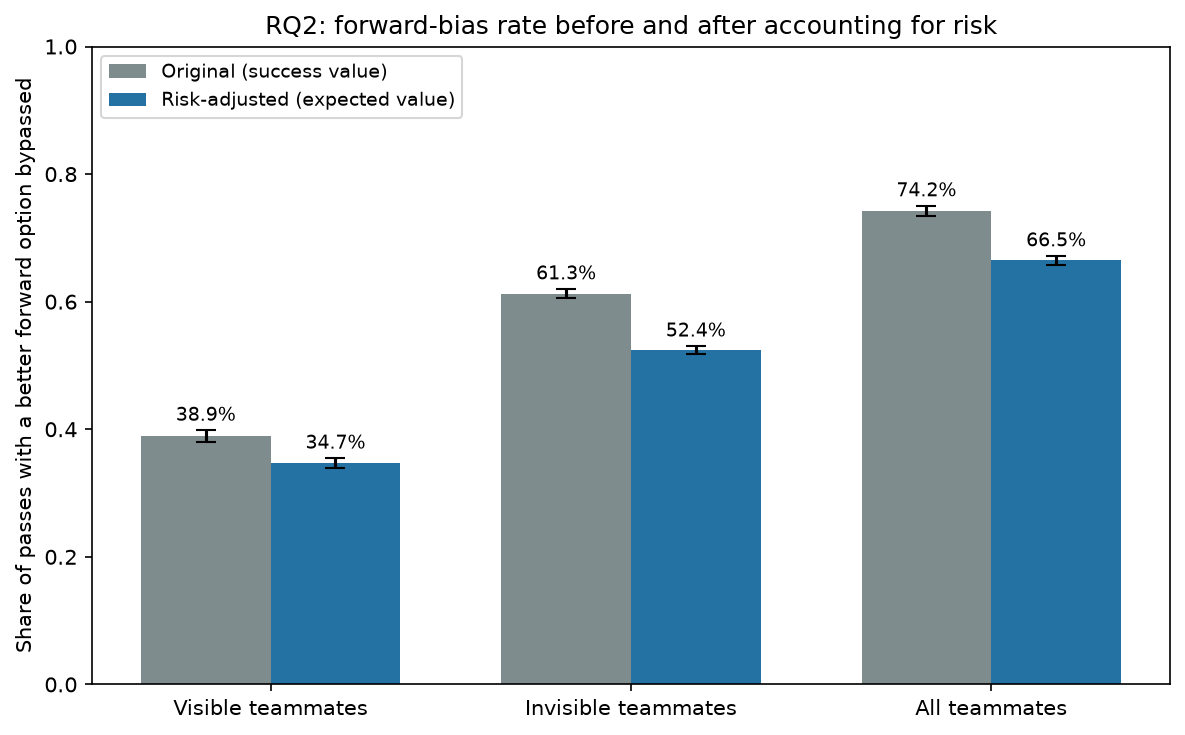

In [7]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
pools = ['visible', 'invisible', 'all']
labels = ['Visible teammates', 'Invisible teammates', 'All teammates']
xpos = np.arange(len(pools))
width = 0.36
for k, (suffix, name, colour) in enumerate([('orig', 'Original (success value)', '#7f8c8d'),
                                            ('ra', 'Risk-adjusted (expected value)', '#2471a3')]):
    r = rq2_risk.loc[[f'{p}_{suffix}' for p in pools]]
    ax.bar(xpos + (k - 0.5) * width, r['rate'], width, color=colour, label=name,
           yerr=[r['rate'] - r['ci_low'], r['ci_high'] - r['rate']], capsize=5, ecolor='black')
    for x, v, top in zip(xpos + (k - 0.5) * width, r['rate'], r['ci_high']):
        ax.text(x, top + 0.015, f"{v:.1%}", ha='center', fontsize=9)
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel('Share of passes with a better forward option bypassed')
ax.set_ylim(0, 1)
ax.set_title('RQ2: forward-bias rate before and after accounting for risk')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / 'rq2_risk_adjusted_rates.png', dpi=300, bbox_inches='tight')
plt.show()

**What this shows:** the same numbers as a chart. Risk adjustment lowers each pool by 4 to 9 percentage points, the order of the pools stays the same, and in every pool the original and risk-adjusted intervals do not overlap.

## 3. Context: when is the bias rate higher or lower?

The pass-level flags are joined to the per-pass information from section 1 and grouped six ways. For each group the table shows the number of passes, the average number of visible teammates (more visible teammates means more chances for one of them to be a better option, so this matters when comparing groups), and the original and risk-adjusted bias rates with match-bootstrap intervals.

In [8]:
ctx = pass_level.merge(pass_info, on=['match_id', 'original_event_id'], how='left')

diff = ctx['goals_for'] - ctx['goals_against']
ctx['score_state'] = np.select([diff < 0, diff == 0, diff > 0], ['Losing', 'Drawing', 'Winning'], default=None)

def minute_bin(period, minute):
    if period >= 3:
        return 'Extra time'
    if period == 1:
        minute = min(minute, 44)        # first-half stoppage time stays in 30-45
    if minute >= 90:
        return '90+'
    lo = (minute // 15) * 15
    return f"{lo}-{lo + 15}"
ctx['minute_bin'] = [minute_bin(p, m) for p, m in zip(ctx['period'], ctx['minute'])]

ctx['pressure'] = np.where(ctx['under_pressure'], 'Under pressure', 'Not under pressure')
ctx['opp_dist_bin'] = pd.cut(ctx['passer_nearest_opp'], [-0.01, 3, 6, 10, 1000],
                             labels=['<3 yd', '3-6 yd', '6-10 yd', '10+ yd']).astype(str)
ctx['position_group'] = ctx['position'].map(position_group)
ctx['third'] = pd.cut(ctx['px'], [-0.01, 40, 80, 120.01],
                      labels=['Defensive third', 'Middle third', 'Attacking third']).astype(str)
ctx['competition'] = ctx['match_id'].map(competition_of)

FACTORS = {
    'score_state': ['Losing', 'Drawing', 'Winning'],
    'minute_bin': ['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+', 'Extra time'],
    'pressure': ['Not under pressure', 'Under pressure'],
    'opp_dist_bin': ['<3 yd', '3-6 yd', '6-10 yd', '10+ yd'],
    'position_group': ['GK', 'DEF', 'MID', 'FWD'],
    'third': ['Defensive third', 'Middle third', 'Attacking third'],
}
print("passes with no position group:", ctx['position_group'].isna().sum())


def rates_by(df, factor, levels):
    out = []
    for lvl in levels:
        sub = df[df[factor] == lvl]
        if len(sub) == 0:
            continue
        r = rate_ci(sub, ['visible_orig', 'visible_ra'])
        out.append({'group': lvl, 'passes': len(sub), 'mean_visible': sub['n_visible'].mean(),
                    'bias_rate': r.loc['visible_orig', 'rate'],
                    'bias_low': r.loc['visible_orig', 'ci_low'], 'bias_high': r.loc['visible_orig', 'ci_high'],
                    'risk_adj_rate': r.loc['visible_ra', 'rate'],
                    'risk_adj_low': r.loc['visible_ra', 'ci_low'], 'risk_adj_high': r.loc['visible_ra', 'ci_high']})
    return pd.DataFrame(out)


context_tables = {}
for factor, levels in FACTORS.items():
    t = rates_by(ctx, factor, levels)
    context_tables[factor] = t
    print(f"\n{factor}")
    print(t.round(3).to_string(index=False))

passes with no position group: 0

score_state
  group  passes  mean_visible  bias_rate  bias_low  bias_high  risk_adj_rate  risk_adj_low  risk_adj_high
 Losing   24541         2.332      0.414     0.398      0.428          0.371         0.358          0.385
Drawing   52364         2.273      0.389     0.378      0.400          0.346         0.337          0.355
Winning   21747         2.170      0.364     0.348      0.380          0.324         0.310          0.337

minute_bin
     group  passes  mean_visible  bias_rate  bias_low  bias_high  risk_adj_rate  risk_adj_low  risk_adj_high
      0-15   16575         2.315      0.379     0.366      0.392          0.337         0.326          0.347
     15-30   15546         2.269      0.387     0.375      0.399          0.341         0.330          0.352
     30-45   17218         2.278      0.396     0.384      0.407          0.353         0.342          0.363
     45-60   15059         2.249      0.380     0.368      0.392          0.339   

**What this shows**

**Score.** The rate is highest when the passer's team is losing (41.4 percent), then drawing (38.9), then winning (36.4); risk-adjusted 37.1, 34.6 and 32.4. Teams that are behind leave slightly more forward options unused, and teams that are ahead slightly fewer. These passes also differ in how many visible teammates they have (2.33, 2.27 and 2.17), so section 4 checks whether the difference survives once that is held fixed.

**Minute.** Almost flat: between 37.9 and 40.2 percent in every 15-minute band, with a slight rise toward the end of normal time (40.2 percent in minutes 75 to 90).

**Pressure.** Much lower when the passer is under pressure: 29.8 against 40.5 percent (risk-adjusted 26.6 against 36.1). The distance to the nearest opponent shows a clear gradient:

| Nearest opponent | Bias rate |
|---|---|
| within 3 yd | 32.8 |
| 3 to 6 yd | 39.1 |
| 6 to 10 yd | 44.2 |
| beyond 10 yd | 45.0 |

Pressured passers also have fewer visible teammates (2.00 against 2.31), so part of this is simply fewer options to bypass.

**Position.** Highest for defenders (41.9 percent), then midfielders (39.1), lowest for forwards (29.3) and goalkeepers (29.9). Risk adjustment lowers the outfield groups by about 4 to 5 points, but raises goalkeepers slightly (to 31.0). Goalkeepers' own passes are often long and risky, so once the real pass also carries its risk, a safer forward option beats it more often.

**Pitch third.** Lowest in the defensive third (30.0 percent), higher in the middle (42.4) and attacking thirds (41.3). Risk adjustment barely changes the defensive third (29.4) but lowers the middle and attacking thirds by 6 and 4 points. The forward options bypassed further up the pitch are the riskier ones.

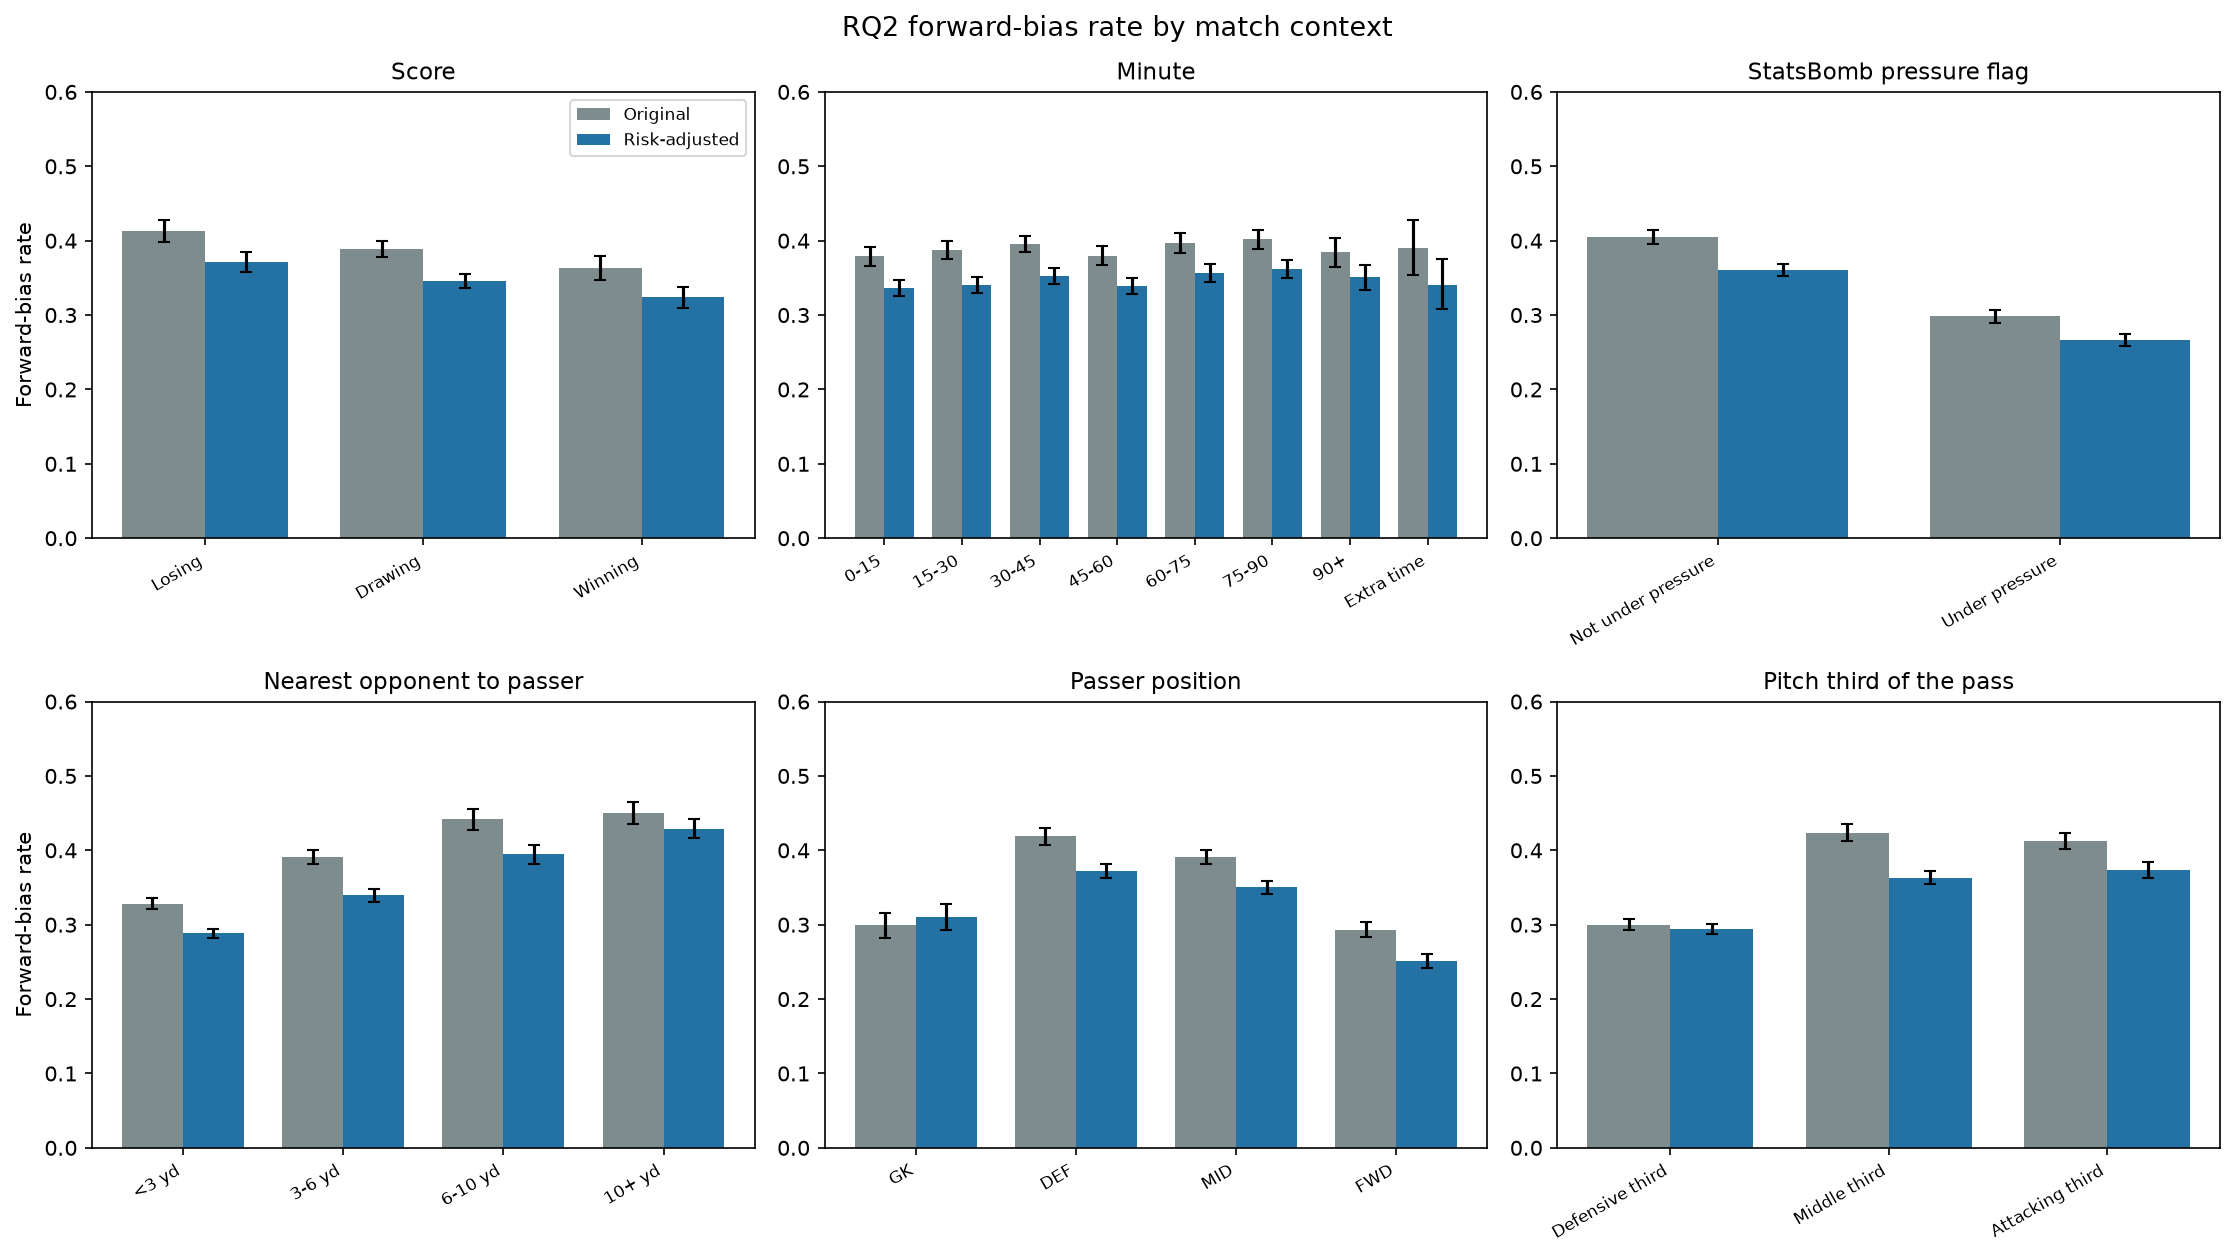

In [9]:
titles = {'score_state': 'Score', 'minute_bin': 'Minute', 'pressure': 'StatsBomb pressure flag',
          'opp_dist_bin': 'Nearest opponent to passer', 'position_group': 'Passer position',
          'third': 'Pitch third of the pass'}
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), dpi=150)
for ax, (factor, t) in zip(axes.ravel(), context_tables.items()):
    x = np.arange(len(t))
    for k, (pre, name, colour) in enumerate([('bias', 'Original', '#7f8c8d'),
                                             ('risk_adj', 'Risk-adjusted', '#2471a3')]):
        rate, lo, hi = t[f'{pre}_rate'], t[f'{pre}_low'], t[f'{pre}_high']
        ax.bar(x + (k - 0.5) * 0.38, rate, 0.38, color=colour, label=name,
               yerr=[rate - lo, hi - rate], capsize=3, ecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(t['group'], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, max(0.6, t['bias_rate'].max() + 0.1))
    ax.set_title(titles[factor], fontsize=11)
axes[0, 0].set_ylabel('Forward-bias rate')
axes[1, 0].set_ylabel('Forward-bias rate')
axes[0, 0].legend(fontsize=8)
fig.suptitle('RQ2 forward-bias rate by match context', fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS / 'rq2_context_rates.png', dpi=300, bbox_inches='tight')
plt.show()

**What this shows:** the six panels summarise the tables. The clearest differences are pressure, distance to the nearest opponent, position and pitch third. Score and minute vary much less. Risk adjustment lowers almost every bar by a similar amount; the exceptions are goalkeepers and the defensive third, where it changes little.

## 4. All context factors together

The group rates above look at one factor at a time, but the factors overlap (defenders mostly pass from the defensive third, pressure is higher in the attacking third, and so on). A logistic regression with all of them at once shows which factors still matter once the others are held fixed. The number of visible teammates is included as a control, since passes with more visible options are more likely to have a better one by chance. Standard errors are clustered by match, the same reason the bootstrap resamples matches: passes in the same match are not independent.

Results are odds ratios: above 1 means more likely to bypass a better forward option than the reference group, below 1 means less likely. Reference groups: Drawing, minute 0-15, not under pressure, nearest opponent 10+ yd, MID, middle third.

In [10]:
import statsmodels.formula.api as smf   # pip install statsmodels if this import fails

reg = ctx.dropna(subset=['score_state', 'position_group']).copy()
reg['y_orig'] = reg['visible_orig'].astype(int)
reg['y_ra'] = reg['visible_ra'].astype(int)
reg['under_pressure'] = reg['under_pressure'].astype(int)
reg['match_code'] = reg['match_id'].astype('category').cat.codes

rhs = ("C(score_state, Treatment('Drawing')) + C(minute_bin, Treatment('0-15'))"
       " + under_pressure + C(opp_dist_bin, Treatment('10+ yd'))"
       " + C(position_group, Treatment('MID')) + C(third, Treatment('Middle third'))"
       " + n_visible")
if reg['competition'].notna().all():
    rhs += " + C(competition)"

regression_tables = {}
for y, name in [('y_orig', 'Original bias flag'), ('y_ra', 'Risk-adjusted bias flag')]:
    fit = smf.logit(f"{y} ~ {rhs}", data=reg).fit(
        disp=0, cov_type='cluster', cov_kwds={'groups': reg['match_code']})
    ci = fit.conf_int()
    table = pd.DataFrame({'odds_ratio': np.exp(fit.params), 'ci_low': np.exp(ci[0]),
                          'ci_high': np.exp(ci[1]), 'p_value': fit.pvalues}).drop(index='Intercept')
    table.index = (table.index.str.replace(r"C\((\w+), Treatment\('[^']*'\)\)\[T\.", r"\1 = ", regex=True)
                              .str.replace(r"C\((\w+)\)\[T\.", r"\1 = ", regex=True).str.rstrip(']'))
    regression_tables[name] = table
    print(f"\n{name}: {int(fit.nobs)} passes, {reg['match_id'].nunique()} matches, pseudo R2 {fit.prsquared:.3f}")
    print(table.round(3).to_string())


Original bias flag: 98652 passes, 166 matches, pseudo R2 0.205
                              odds_ratio  ci_low  ci_high  p_value
score_state = Losing               1.040   0.981    1.102    0.184
score_state = Winning              0.939   0.889    0.993    0.027
minute_bin = 15-30                 1.069   1.013    1.129    0.016
minute_bin = 30-45                 1.099   1.031    1.172    0.004
minute_bin = 45-60                 1.057   0.994    1.124    0.076
minute_bin = 60-75                 1.136   1.071    1.205    0.000
minute_bin = 75-90                 1.161   1.085    1.242    0.000
minute_bin = 90+                   1.101   1.015    1.195    0.021
minute_bin = Extra time            1.031   0.915    1.161    0.616
opp_dist_bin = 3-6 yd              0.819   0.773    0.867    0.000
opp_dist_bin = 6-10 yd             0.881   0.832    0.934    0.000
opp_dist_bin = <3 yd               0.694   0.650    0.740    0.000
position_group = DEF               1.157   1.114    1.202    0.00

**What this shows**

All factors are in the model together, with match-clustered standard errors. An odds ratio of 1.16 means 16 percent higher odds of bypassing a better forward option than the reference group, holding the other factors fixed.

**Number of visible teammates (the strongest effect, and mostly mechanical).** Each extra visible teammate multiplies the odds by 1.94 (1.66 risk-adjusted), since every extra option is another chance for one of them to be better than the pass played. This control matters for reading the rest.

**Pitch location.** With the number of options held fixed, passes from the attacking third have higher odds than passes from the middle third (1.59, risk-adjusted 1.65). Passes from the defensive third have lower odds (0.56, risk-adjusted 0.74). The raw attacking-third rate looked slightly below the middle third only because attacking-third passes have fewer visible teammates (1.96 against 2.41).

**Pressure.** Both pressure measures lower the odds independently of each other and of the number of options:

- StatsBomb's pressure flag: 0.84 (risk-adjusted 0.88);
- an opponent within 3 yd: 0.69 against 10 yd or more (risk-adjusted 0.60), with 3 to 6 yd at 0.82 and 6 to 10 yd at 0.88.

Under close pressure, passers less often leave a better forward option unused.

**Position.** Forwards have the lowest odds (0.57 against midfielders), and goalkeepers lower odds too (0.80). Defenders have higher odds on the original flag (1.16), and after risk adjustment this shrinks to 1.04 (interval 1.00 to 1.08, p = 0.07).

The refined model further down shows that the goalkeeper and defender results depend on how finely pitch location is modelled, so only the forwards result should be read as robust.

**Game state (real but small).**

- Winning lowers the odds slightly (0.94, p = 0.03); losing does not differ clearly from drawing (1.04, p = 0.18).
- Odds rise gradually through a match, from the reference 0-15 band up to 1.14 in minutes 60 to 75 and 1.16 in minutes 75 to 90. Extra time does not differ from the opening 15 minutes.

**Competition.** The World Cup 2022 (0.89) and Euro 2024 (0.93) are slightly lower than Euro 2020.

The model explains a moderate part of the variation (pseudo R2 0.205, risk-adjusted 0.143). Overall, the biggest influences on whether a pass bypasses a better forward option are how many options there are, where the pass is from, who passes, and pressure. Score and minute change the odds by at most about 16 percent.

**Is logistic regression the right model?** The regression above is for explanation: one odds ratio per factor with a confidence interval. A more flexible model could predict the flag better without giving effect sizes, so the check here is whether flexible models find much more signal. Four models are compared on held-out matches (5 folds, whole matches kept together): the logistic regression as reported, gradient boosting on the same binned factors, and gradient boosting and a random forest on the raw, unbinned variables (exact minute, exact distance to nearest opponent, exact x and y). If the flexible models are only slightly ahead (AUC within about 0.01 to 0.02), the logistic regression is not missing important structure. Permutation importance shows which variables the most flexible model relies on, to compare against the regression's ranking. This cell takes a few minutes.

In [11]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.inspection import permutation_importance

# the same passes as the regression above
data = reg.copy()
data['score_diff'] = (data['goals_for'] - data['goals_against']).clip(-3, 3)
groups = data['match_id'].values

# A: the binned factors, exactly as in the logistic regression
binned = pd.get_dummies(data[['score_state', 'minute_bin', 'opp_dist_bin', 'position_group', 'third']
                             + (['competition'] if data['competition'].notna().all() else [])],
                        drop_first=True, dtype=float)
binned['under_pressure'] = data['under_pressure'].astype(float)
binned['n_visible'] = data['n_visible'].astype(float)

# B: the same information without binning, so a flexible model can find thresholds and interactions itself
raw = pd.DataFrame({
    'score_diff': data['score_diff'],
    'minute': data['minute'],
    'extra_time': (data['period'] >= 3).astype(float),
    'under_pressure': data['under_pressure'].astype(float),
    'passer_nearest_opp': data['passer_nearest_opp'].clip(upper=30),
    'passer_x': data['px'],
    'passer_y': data['py'],
    'n_visible': data['n_visible'].astype(float),
})
raw = pd.concat([raw, pd.get_dummies(data['position_group'], prefix='pos', dtype=float)], axis=1)
if data['competition'].notna().all():
    raw = pd.concat([raw, pd.get_dummies(data['competition'], prefix='comp', drop_first=True, dtype=float)], axis=1)

models = {
    'logistic regression (binned, as reported)': (lambda: LogisticRegression(max_iter=2000), binned),
    'gradient boosting (binned)': (lambda: HistGradientBoostingClassifier(random_state=0), binned),
    'gradient boosting (raw, unbinned)': (lambda: HistGradientBoostingClassifier(random_state=0), raw),
    'random forest (raw, unbinned)': (lambda: RandomForestClassifier(n_estimators=100, min_samples_leaf=50,
                                                                     n_jobs=-1, random_state=0), raw),
}

# 5 folds that keep whole matches together, so no match is in both training and test data
gkf = GroupKFold(n_splits=5)
rows = []
for y_col, y_name in [('y_orig', 'original flag'), ('y_ra', 'risk-adjusted flag')]:
    y = data[y_col].values
    for name, (make, X) in models.items():
        aucs, losses = [], []
        for tr, te in gkf.split(X, y, groups):
            m = make().fit(X.iloc[tr], y[tr])
            p = m.predict_proba(X.iloc[te])[:, 1]
            aucs.append(roc_auc_score(y[te], p))
            losses.append(log_loss(y[te], p))
        rows.append({'outcome': y_name, 'model': name, 'auc_mean': np.mean(aucs), 'auc_sd': np.std(aucs),
                     'log_loss': np.mean(losses)})
model_comparison = pd.DataFrame(rows)
print("Held-out performance, 5 folds split by match:")
print(model_comparison.round(4).to_string(index=False))

# which factors does the most flexible model rely on? permutation importance on held-out matches
tr, te = next(gkf.split(raw, data['y_orig'], groups))
gb = HistGradientBoostingClassifier(random_state=0).fit(raw.iloc[tr], data['y_orig'].values[tr])
te_s = te if len(te) <= 20000 else np.random.default_rng(0).choice(te, 20000, replace=False)
imp = permutation_importance(gb, raw.iloc[te_s], data['y_orig'].values[te_s], scoring='roc_auc',
                             n_repeats=5, random_state=0)
importance = pd.DataFrame({'drop_in_auc': imp.importances_mean, 'sd': imp.importances_std},
                          index=raw.columns).sort_values('drop_in_auc', ascending=False)
print("\nGradient boosting (raw), original flag: how much held-out AUC drops when each feature is shuffled")
print(importance.round(4).to_string())

Held-out performance, 5 folds split by match:
           outcome                                     model  auc_mean  auc_sd  log_loss
     original flag logistic regression (binned, as reported)    0.8050  0.0053    0.5315
     original flag                gradient boosting (binned)    0.8196  0.0044    0.4908
     original flag         gradient boosting (raw, unbinned)    0.8403  0.0034    0.4669
     original flag             random forest (raw, unbinned)    0.8363  0.0034    0.4843
risk-adjusted flag logistic regression (binned, as reported)    0.7642  0.0048    0.5541
risk-adjusted flag                gradient boosting (binned)    0.7777  0.0037    0.5138
risk-adjusted flag         gradient boosting (raw, unbinned)    0.8006  0.0037    0.4950
risk-adjusted flag             random forest (raw, unbinned)    0.7963  0.0032    0.5091

Gradient boosting (raw), original flag: how much held-out AUC drops when each feature is shuffled
                     drop_in_auc      sd
n_visible    

**What this shows**

**The flexible models do better than the reported logistic regression.** Held-out AUC is 0.840 for gradient boosting on the raw variables against 0.805 for the logistic regression (0.801 against 0.764 for the risk-adjusted flag). That is more than the 0.01 to 0.02 that would mean nothing is missing, so the binned logistic regression does leave some structure out. About 0.015 of the gap comes from interactions between the binned factors (gradient boosting on the same bins), and about 0.02 from detail lost by binning.

**The permutation importance shows where that extra signal is.** It is almost entirely in the number of visible teammates (AUC drops by 0.291 when it is shuffled) and in where the pass starts:

- passer x: 0.058;
- passer y: 0.009, which the reported regression does not include at all;
- distance to the nearest opponent: 0.008;
- position: about 0.007.

Score difference, minute, the pressure flag and competition each matter almost nothing to the flexible model (0.0005 or less).

**What that means.** The extra accuracy comes from modelling the controls (options and pitch location) more finely, not from the game-state factors. The flexible model agrees with the regression that score and minute play only a small part. The logistic regression is still the right tool for reporting effect sizes. The next cell checks that its context odds ratios do not change when pitch location is modelled more finely.

**Refined logistic regression: does finer pitch location change the context results?**

The model comparison showed that the reported regression misses detail in where the pass starts (it only has thirds, and no left-to-right position) and in how the effect of extra visible teammates levels off. This refits the same logistic regression with:

- thirds replaced by 18 pitch zones: six depth bands of 20 yards, each split into central, half-space and wide channels;
- a squared term for the number of visible teammates.

It reports held-out AUC next to the earlier models. It also puts the context odds ratios (score, minute, pressure, position, competition) of the reported and refined models side by side. If those odds ratios barely move, the conclusions about context do not depend on how pitch location is modelled.

In [12]:
import patsy

# finer pitch location: six depth bands by three channels (central, half-space, wide), instead of thirds only
reg['x_band'] = pd.cut(reg['px'], [-0.01, 20, 40, 60, 80, 100, 120.01],
                       labels=['x0-20', 'x20-40', 'x40-60', 'x60-80', 'x80-100', 'x100-120']).astype(str)
from_centre = (reg['py'] - 40).abs()
reg['channel'] = np.select([from_centre < 10, from_centre < 22], ['central', 'half-space'], default='wide')
reg['zone'] = reg['x_band'] + ' ' + reg['channel']

# the same model as reported, with thirds replaced by the 18 zones and a curve (squared term) for visible teammates
rhs_refined = (rhs.replace(" + C(third, Treatment('Middle third'))", "")
                  .replace(" + n_visible", " + n_visible + I(n_visible ** 2)")
               + " + C(zone, Treatment('x40-60 central'))")
assert 'third' not in rhs_refined and 'zone' in rhs_refined

# 1. held-out AUC, same five match-grouped folds as the comparison above
X_reported = patsy.dmatrix(rhs, reg, return_type='dataframe')
X_refined = patsy.dmatrix(rhs_refined, reg, return_type='dataframe')
rows = []
for y_col, y_name in [('y_orig', 'original flag'), ('y_ra', 'risk-adjusted flag')]:
    y = reg[y_col].values
    for name, X in [('logistic regression (as reported)', X_reported),
                    ('logistic regression (refined location)', X_refined)]:
        aucs = []
        for tr, te in GroupKFold(n_splits=5).split(X, y, reg['match_id']):
            m = LogisticRegression(max_iter=5000).fit(X.iloc[tr], y[tr])
            aucs.append(roc_auc_score(y[te], m.predict_proba(X.iloc[te])[:, 1]))
        rows.append({'outcome': y_name, 'model': name, 'auc_mean': np.mean(aucs)})
    best = model_comparison[(model_comparison['outcome'] == y_name)
                            & (model_comparison['model'] == 'gradient boosting (raw, unbinned)')]
    rows.append({'outcome': y_name, 'model': 'gradient boosting (raw, unbinned), from above',
                 'auc_mean': best['auc_mean'].iloc[0]})
print("Held-out AUC:")
print(pd.DataFrame(rows).round(4).to_string(index=False))

# 2. do the context odds ratios change once location is modelled more finely?
def tidy(fit):
    ci = fit.conf_int()
    t = pd.DataFrame({'odds_ratio': np.exp(fit.params), 'ci_low': np.exp(ci[0]),
                      'ci_high': np.exp(ci[1]), 'p_value': fit.pvalues}).drop(index='Intercept')
    t.index = (t.index.str.replace(r"C\((\w+), Treatment\('[^']*'\)\)\[T\.", r"\1 = ", regex=True)
                      .str.replace(r"C\((\w+)\)\[T\.", r"\1 = ", regex=True).str.rstrip(']'))
    return t

refined_tables = {}
for y, name in [('y_orig', 'Original bias flag'), ('y_ra', 'Risk-adjusted bias flag')]:
    fit = smf.logit(f"{y} ~ {rhs_refined}", data=reg).fit(
        disp=0, maxiter=200, cov_type='cluster', cov_kwds={'groups': reg['match_code']})
    refined = tidy(fit)
    refined_tables[name] = refined
    context_terms = [t for t in regression_tables[name].index
                     if not t.startswith(('third', 'n_visible'))]
    side = pd.DataFrame({
        'OR_reported': regression_tables[name].loc[context_terms, 'odds_ratio'],
        'OR_refined': refined.loc[context_terms, 'odds_ratio'],
        'ci_low_refined': refined.loc[context_terms, 'ci_low'],
        'ci_high_refined': refined.loc[context_terms, 'ci_high'],
        'p_refined': refined.loc[context_terms, 'p_value'],
    })
    print(f"\n{name}: context odds ratios, reported model against refined model "
          f"(pseudo R2 {fit.prsquared:.3f})")
    print(side.round(3).to_string())

    zones = refined[refined.index.str.startswith('zone')].sort_values('odds_ratio')
    print(f"\n{name}: pitch zones against the central zone between x = 40 and 60")
    print(zones.round(3).to_string())

Held-out AUC:
           outcome                                         model  auc_mean
     original flag             logistic regression (as reported)    0.8051
     original flag        logistic regression (refined location)    0.8252
     original flag gradient boosting (raw, unbinned), from above    0.8403
risk-adjusted flag             logistic regression (as reported)    0.7642
risk-adjusted flag        logistic regression (refined location)    0.7841
risk-adjusted flag gradient boosting (raw, unbinned), from above    0.8006

Original bias flag: context odds ratios, reported model against refined model (pseudo R2 0.261)
                              OR_reported  OR_refined  ci_low_refined  ci_high_refined  p_refined
score_state = Losing                1.040       1.027           0.974            1.083      0.328
score_state = Winning               0.939       0.953           0.906            1.003      0.064
minute_bin = 15-30                  1.069       1.066           1.011 

**What this shows**

**Finer pitch location closes most of the gap to the flexible models.** Held-out AUC rises from 0.805 to 0.825 (gradient boosting: 0.840), and for the risk-adjusted flag from 0.764 to 0.784 (gradient boosting: 0.801). That is about 60 percent of the gap, so most of what the reported model was missing was simply where on the pitch the pass started. The remaining 0.015 is interactions, for example the same zone mattering differently for different positions. Pseudo R2 rises from 0.205 to 0.261.

**Game state and competition do not change.** The score, minute and competition odds ratios are almost identical in both models. Here are the original-flag numbers:

| Term | Reported | Refined |
|---|---|---|
| Winning | 0.94 | 0.95 (p = 0.06) |
| Minutes 60 to 75 | 1.14 | 1.12 |
| Minutes 75 to 90 | 1.16 | 1.16 |
| World Cup 2022 | 0.89 | 0.89 |

For the risk-adjusted flag, winning is 0.95 (p = 0.03). So the small game-state effects do not depend on how location is modelled.

**Pressure gets slightly stronger.** An opponent within 3 yd goes from 0.69 to 0.63 (risk-adjusted 0.60 to 0.56). The pressure flag goes from 0.84 to 0.87 (risk-adjusted 0.88 to 0.92). Both are still clearly below 1.

**Position does change.** The reported model's position effects were partly standing in for location:

- **Goalkeepers flip** from 0.80 to 1.72 (risk-adjusted 0.82 to 1.80). Goalkeepers pass from the deep central zone, which has the lowest odds of all (0.35). Once that zone is in the model, a goalkeeper is more likely to bypass a forward option than a midfielder passing from the same spot.
- **Defenders** go from 1.16 to 1.40. After risk adjustment they are 1.26, still clearly above 1 (interval 1.21 to 1.31). So the earlier reading, that defenders' extra rate is mostly risk avoidance, only holds with the coarse thirds. With finer location, risk adjustment reduces the defender effect but does not remove it.
- **Forwards** stay low in both models (0.57 and 0.60, risk-adjusted 0.57 and 0.61), so that is the robust position result.

**Pitch zones** (against the central zone between x = 40 and 60):

- **Lowest:** the deep central zone in front of the passer's own goal (0.35, risk-adjusted 0.42) and the central zone just in front of it (0.75).
- **Highest:** the opponent's half. Every zone between x = 60 and 100 is 2.2 to 3.2 times the reference, peaking between x = 80 and 100.
- **Deep wide zone:** high (1.89, risk-adjusted 2.08), which fits full-backs who often have a forward option down the line and play inside instead.
- **Central zone nearest the opponent's goal:** not clearly different from the reference (0.72, interval 0.45 to 1.15). Few passes come from there.

**Conclusion on model choice.** A logistic regression with finer location is good enough for reporting: it gets most of the way to the flexible models and keeps interpretable odds ratios. The game-state and pressure results are the same in both versions. Position effects should be reported from the refined model, with the caveat that position and pitch location overlap a lot.

## Figures for the progress presentation

These cells make the charts used in the progress presentation, in the deck's colours, from this notebook's own results, so every figure in the slides can be reproduced. They are saved to `../data/results/figures/`. They do not change any result.

Slides: "Where we are now", "Is It Just Risk Avoidance?", "When Does It Happen?" and the "Model Check" backup. The context chart shows selected terms from the refined model. "Opponent half" is the central zone between x = 80 and 100 yards and "Own box area" the central zone between x = 0 and 20, both against the central zone between x = 40 and 60; every other factor is against its own reference group (midfielders, minutes 0 to 15, drawing, and no opponent within 10 yd).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# deck colours and style, shared by the presentation figures below
FIG_DIR = Path('../data/results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
NAVY, GREEN, GREY, LIGHT, TXT = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0', '#1B1B1F'
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#6B7280', 'axes.labelcolor': TXT,
                     'xtick.color': TXT, 'ytick.color': '#6B7280'})


def deck_bars(ax, labels, vals, colours, lo=None, hi=None, fmt='{:.1f}%', ymax=None, off=1.0):
    """Bar chart in the deck's style, with optional confidence intervals and value labels."""
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colours, width=0.62)
    if lo is not None:
        ax.errorbar(x, vals, yerr=[np.subtract(vals, lo), np.subtract(hi, vals)],
                    fmt='none', ecolor=TXT, capsize=5, lw=1.2)
    for i, v in enumerate(vals):
        top = hi[i] if hi is not None else v
        ax.text(i, top + off, fmt.format(v), ha='center', va='bottom', fontsize=13, fontweight='bold', color=TXT)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    if ymax:
        ax.set_ylim(0, ymax)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=250, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"saved {FIG_DIR / name}")

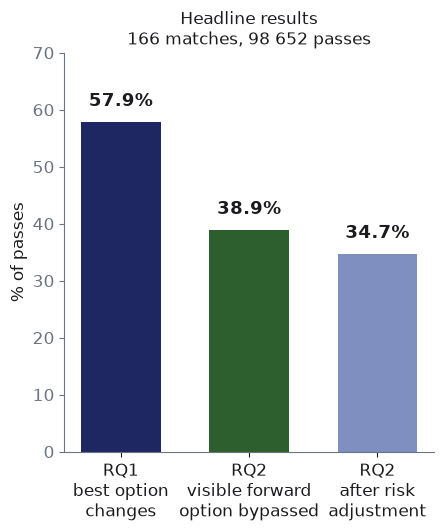

saved ..\data\results\figures\slide_where_we_are.png
[57.9, 38.9, 34.7]


In [14]:
# "Where we are now" chart: RQ1 headline, RQ2 headline, RQ2 after risk adjustment
rq1 = pd.read_pickle(RESULTS / 'rq1_summary_stats_all3_fixed.pkl')
vals = [100 * rq1['proportion_identity_changed'],
        100 * rq2_risk.loc['visible_orig', 'rate'],
        100 * rq2_risk.loc['visible_ra', 'rate']]
fig, ax = plt.subplots(figsize=(4.77, 5.18))
deck_bars(ax, ['RQ1\nbest option\nchanges', 'RQ2\nvisible forward\noption bypassed', 'RQ2\nafter risk\nadjustment'],
          vals, [NAVY, GREEN, LIGHT], ymax=70, off=2)
ax.set_ylabel('% of passes')
n_passes = f"{rq1['total_passes_compared']:,}".replace(',', ' ')
ax.set_title(f"Headline results\n166 matches, {n_passes} passes", fontsize=12, color=TXT)
save_fig(fig, 'slide_where_we_are.png')
print([round(v, 1) for v in vals])

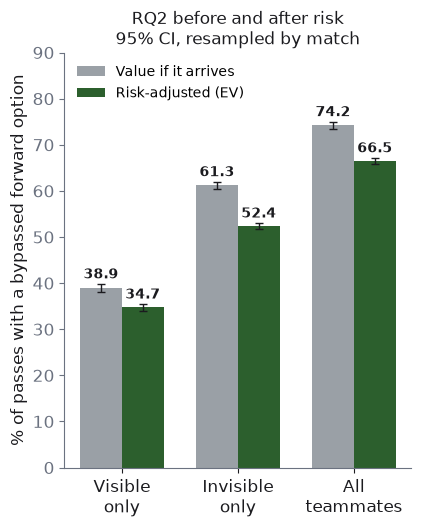

saved ..\data\results\figures\slide_risk.png


In [15]:
# risk chart: forward-bias rate per option pool, before and after risk adjustment (from rq2_risk above)
pools = ['visible', 'invisible', 'all']
fig, ax = plt.subplots(figsize=(4.48, 5.39))
x, w = np.arange(3), 0.36
for shift, suffix, colour, label in [(-w / 2, 'orig', GREY, 'Value if it arrives'),
                                     (w / 2, 'ra', GREEN, 'Risk-adjusted (EV)')]:
    r = rq2_risk.loc[[f'{p}_{suffix}' for p in pools]] * [1, 100, 100, 100]
    ax.bar(x + shift, r['rate'], w, color=colour, label=label)
    ax.errorbar(x + shift, r['rate'], yerr=[r['rate'] - r['ci_low'], r['ci_high'] - r['rate']],
                fmt='none', ecolor=TXT, capsize=3, lw=1)
    for xi, v, top in zip(x + shift, r['rate'], r['ci_high']):
        ax.text(xi, top + 1.2, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold', color=TXT)
ax.set_xticks(x)
ax.set_xticklabels(['Visible\nonly', 'Invisible\nonly', 'All\nteammates'])
ax.set_ylim(0, 90)
ax.set_ylabel('% of passes with a bypassed forward option')
ax.legend(frameon=False, loc='upper left', fontsize=10)
ax.set_title('RQ2 before and after risk\n95% CI, resampled by match', fontsize=12, color=TXT)
save_fig(fig, 'slide_risk.png')

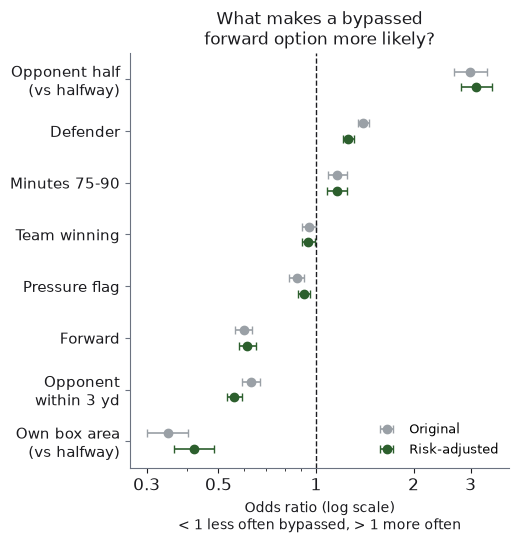

saved ..\data\results\figures\slide_context.png


In [16]:
import matplotlib.ticker
# context chart: selected odds ratios from the refined model (refined_tables, from the refined regression cell)
terms = [
    ('zone = x80-100 central', 'Opponent half\n(vs halfway)'),
    ('position_group = DEF', 'Defender'),
    ('minute_bin = 75-90', 'Minutes 75-90'),
    ('score_state = Winning', 'Team winning'),
    ('under_pressure', 'Pressure flag'),
    ('position_group = FWD', 'Forward'),
    ('opp_dist_bin = <3 yd', 'Opponent\nwithin 3 yd'),
    ('zone = x0-20 central', 'Own box area\n(vs halfway)'),
]
fig, ax = plt.subplots(figsize=(4.9, 5.39))
y = np.arange(len(terms))[::-1]
for name, colour, shift, label in [('Original bias flag', GREY, 0.15, 'Original'),
                                   ('Risk-adjusted bias flag', GREEN, -0.15, 'Risk-adjusted')]:
    t = refined_tables[name].loc[[k for k, _ in terms]]
    ax.errorbar(t['odds_ratio'], y + shift,
                xerr=[t['odds_ratio'] - t['ci_low'], t['ci_high'] - t['odds_ratio']],
                fmt='o', color=colour, ms=6, capsize=3, lw=1.2, label=label)
ax.axvline(1, color=TXT, lw=1, ls='--')
ax.set_xscale('log')
ax.set_xticks([0.3, 0.5, 1, 2, 3])
ax.set_xticklabels(['0.3', '0.5', '1', '2', '3'])
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())   # hide the automatic minor-tick labels
ax.set_yticks(y)
ax.set_yticklabels([lab for _, lab in terms], fontsize=11, color=TXT)
ax.set_xlabel('Odds ratio (log scale)\n< 1 less often bypassed, > 1 more often', fontsize=10)
ax.legend(frameon=False, loc='lower right', fontsize=9)
ax.set_title('What makes a bypassed\nforward option more likely?', fontsize=12, color=TXT)
save_fig(fig, 'slide_context.png')

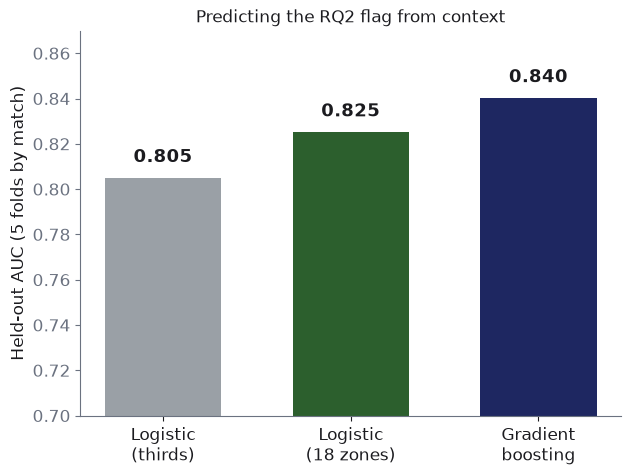

saved ..\data\results\figures\slide_model_check.png


In [17]:
# model check chart (backup slide): held-out AUC for the original flag
auc_refined = pd.DataFrame(rows)   # the AUC table built in the refined regression cell
mc = model_comparison[model_comparison['outcome'] == 'original flag'].set_index('model')['auc_mean']
ar = auc_refined[auc_refined['outcome'] == 'original flag'].set_index('model')['auc_mean']
vals = [mc['logistic regression (binned, as reported)'],
        ar['logistic regression (refined location)'],
        mc['gradient boosting (raw, unbinned)']]
fig, ax = plt.subplots(figsize=(6.98, 5.0))
deck_bars(ax, ['Logistic\n(thirds)', 'Logistic\n(18 zones)', 'Gradient\nboosting'], vals,
          [GREY, GREEN, NAVY], fmt='{:.3f}', off=0.005)
ax.set_ylim(0.7, 0.87)
ax.set_ylabel('Held-out AUC (5 folds by match)')
ax.set_title('Predicting the RQ2 flag from context', fontsize=12, color=TXT)
save_fig(fig, 'slide_model_check.png')

In [18]:
pass_level_out = ctx.drop(columns=['position'])
pass_level_out.to_pickle(RESULTS / 'rq2_risk_context_pass_level.pkl')
pd.to_pickle({'rates': rq2_risk, 'context': context_tables, 'regression': regression_tables},
             RESULTS / 'rq2_risk_context_summary.pkl')
candidates_full[['match_id', 'original_event_id', 'cand_x', 'cand_y', 'candidate_value_fail',
                 'real_value_fail', 'real_xp', 'ev_candidate', 'ev_real', 'legit_ra']].to_pickle(
    RESULTS / 'candidates_risk_values.pkl')
print("Saved:")
print("  ../data/results/rq2_risk_context_pass_level.pkl")
print("  ../data/results/rq2_risk_context_summary.pkl")
print("  ../data/results/candidates_risk_values.pkl")

Saved:
  ../data/results/rq2_risk_context_pass_level.pkl
  ../data/results/rq2_risk_context_summary.pkl
  ../data/results/candidates_risk_values.pkl


## Summary

**Risk.** Giving every option and every real pass an expected value lowers the RQ2 forward-bias rate from 38.9 to 34.7 percent (95 percent interval 34.0 to 35.5), and 79.2 percent of the originally flagged passes are still flagged.

- Even under the strictest version, where only the bypassed option is penalised for risk, 23.4 percent of passes bypass a better visible forward option.
- Bypassed options are riskier than the passes chosen (mean xP 0.616 against 0.876), so part of the original rate is sensible risk avoidance, but most of it is not.
- The gap between the omniscient and perception-aware rates survives (66.5 against 34.7 percent).

H2 holds with risk included.

**Context.** Holding everything else fixed (refined model, original flag; risk-adjusted in brackets):

- **Visible teammates:** the strongest factor is how many a passer has.
- **Pitch location:** passes from the opponent's half (x = 60 to 100) are 2 to 3 times more likely to be flagged than passes from the central zone around halfway. Passes from deep central areas are least likely.
- **Pressure:** pressure on the passer lowers the rate. An opponent within 3 yd: 0.63 (0.56). StatsBomb's pressure flag: 0.87 (0.92).
- **Position:** forwards bypass forward options least (0.60, 0.61), and defenders more than midfielders (1.40, 1.26). The goalkeeper and defender estimates depend on how pitch location is modelled, so forwards are the robust position result.
- **Game state:** real but small effects. Teams that are winning bypass slightly less (0.95). The odds rise slowly through the match, to about 1.16 in minutes 75 to 90. These numbers are the same in the reported and refined models.

**Model choice.** Gradient boosting predicts the flag best (AUC 0.840), but its advantage comes almost entirely from modelling the number of options and pitch location in more detail. A logistic regression with 18 pitch zones gets most of the way there (0.825) and keeps interpretable odds ratios, so it is used for reporting. Game-state and pressure results are unchanged between the two logistic models.

**Units.** All distance bins are in StatsBomb yards: 3, 6 and 10 yd are 2.7, 5.5 and 9.1 m.